---
title: "Chapter 4, Part 3: Baseline Models"
subtitle: "Machine Learning"
date: "March 2026"
date-format: "MMMM YYYY"
author: 
  - F.San Segundo & N.Rodríguez
bibliography: ../exclude/mlmiin.bib
execute:
  echo: true
code-overflow: wrap
format: 
  html: 
    toc: true
    code-tools: true
    code-fold: show
    code-summary: "Hide the code"
    embed-resources: true
---

---

::: {.callout-warning icon=false}

##### Setting the working directory

We begin by using cd to make sure we are in the right folder.

:::

In [234]:
%cd /wd/4_3_Baseline

/wd/4_3_Baseline


---

# Session Setup

::: {.callout-note  icon=false}

### Install additional libraries

We need to install some libraries from the [Nixtlaverse](https://nixtlaverse.nixtla.io/)

:::



In [235]:
import subprocess

def pip_install(package):
    result = subprocess.run(
        ["pip", "install", package],
        capture_output=True,
        text=True
    )
    if result.returncode != 0:
        print(f"Error installing {package}: {result.stderr}")
    else:
        print(f"Successfully installed {package}")

pip_install("fpppy")
pip_install("tsfeatures")
pip_install("pyreadr")

::: {.callout-note  icon=false}

### Libraries

Let us also load the libraries we will use.

:::



In [236]:
# 1. System and Environment Setup
import os
import sys
import warnings
import random
import datetime
from tqdm import tqdm

# Set environment variables and ignore specific warnings
os.environ["NIXTLA_ID_AS_COL"] = "true"
warnings.filterwarnings(
    "ignore", 
    category=UserWarning, 
    message=".*FigureCanvasAgg is non-interactive.*"
)

# 2. Core Data Science Stack
import numpy as np
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose

from statsforecast.arima import ARIMASummary, ndiffs, nsdiffs


# 3. Time Series & Machine Learning
import pmdarima as pmd
import yfinance as yf
import rdatasets
import pyreadr
from sktime.datasets import load_airline
from sktime.utils.plotting import plot_series as plot_series_sktime

# 4. Custom Utilities
from fc_4_3_utils.utils import *
from fpppy.utils import plot_series as plot_series_fpp
from utilsforecast.plotting import plot_series as plot_series_utils

from utilsforecast.evaluation import evaluate
from utilsforecast.losses import rmse, mape
from statsforecast import StatsForecast

from statsforecast.models import (
    HistoricAverage,
    Naive,
    RandomWalkWithDrift,
    SeasonalNaive,
)

from statsforecast.models import MSTL



# 5. Global Reproducibility & Display Settings
np.random.seed(1)
random.seed(1)
np.set_printoptions(suppress=True)

pd.set_option("max_colwidth", 100)
pd.set_option("display.precision", 3)

# 6. Plotting Configuration
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from cycler import cycler

# Jupyter Magic
%matplotlib inline
%config InlineBackend.figure_format = 'png' # High-res plots

# Style and Aesthetics
plt.style.use("ggplot")
sns.set_style("whitegrid")

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "figure.constrained_layout.use": True,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.title_fontsize": 10,
})

# Custom color cycle (Example: monochromatic black as per your original)
mpl.rcParams['axes.prop_cycle'] = cycler(color=["#000000", "#000000"])

In [237]:
import warnings
import os

# Ignore all warnings
warnings.filterwarnings("ignore")

# Specifically target Scikit-Learn/FutureWarnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Some environments also require setting an environment variable
os.environ['PYTHONWARNINGS'] = 'ignore'

---

# Train / Test splits and validation in time series forecasting


::: {.callout-note icon=false}

#### Temporal train-test splits

In time series forecasting, we need to be careful when splitting the data into training and testing sets. We cannot use random splits, because we need to preserve the temporal order of the data and we must avoid using future unknown data to predict past data. 

Therefore we need to use **time-aware splits**, where the training set contains the data up to a certain point in time, and the testing set contains the data after that point. The split is often performed directly by splitting the data into two parts, but some libraries (like `sktime`) have functions to perform this split.

**Highly recommended reading and video watching:** [@hyndman2021fpp3, Section 5.8](https://otexts.com/fpp3/accuracy.html#accuracy)

:::


We will use the **Canadian gas production dataset** to illustrate these splitting methods.


In [238]:
cgas = pd.read_csv('../4_1_Introduction_to_Forecasting/tsdata/fpp3/Canadian_gas.csv')
cgas.head()


,Month,Volume
0,1960 Jan,1.431
1,1960 Feb,1.306
2,1960 Mar,1.402
3,1960 Apr,1.170
4,1960 May,1.116


In [239]:
cgas["Month"] = pd.to_datetime(cgas["Month"], format="%Y %b")
cgas.head()


,Month,Volume
0,1960-01-01,1.431
1,1960-02-01,1.306
2,1960-03-01,1.402
3,1960-04-01,1.170
4,1960-05-01,1.116


In [240]:
# Set 'Month' as index and set frequency as Month end, required by sktime
cgas["Month"] = cgas["Month"] + pd.offsets.MonthEnd(0)
cgas.set_index("Month", inplace=True)
cgas.index.freq = 'M'

cgas.head()


,Volume
Month,
1960-01-31,1.431
1960-02-29,1.306
1960-03-31,1.402
1960-04-30,1.170
1960-05-31,1.116


Let us also create a Nixtla format time series for this example.

In [241]:
fpppy_path = '/wd/data/fpppy/'
cgas_nx = pd.read_csv(fpppy_path + '/canadian_gas.csv', parse_dates=['ds'])
cgas_nx.tail()

,unique_id,ds,y
537,Canadian gas production,2004-10-01,17.827
538,Canadian gas production,2004-11-01,17.832
539,Canadian gas production,2004-12-01,19.453
540,Canadian gas production,2005-01-01,19.528
541,Canadian gas production,2005-02-01,16.944


Recall the time plot of the series:

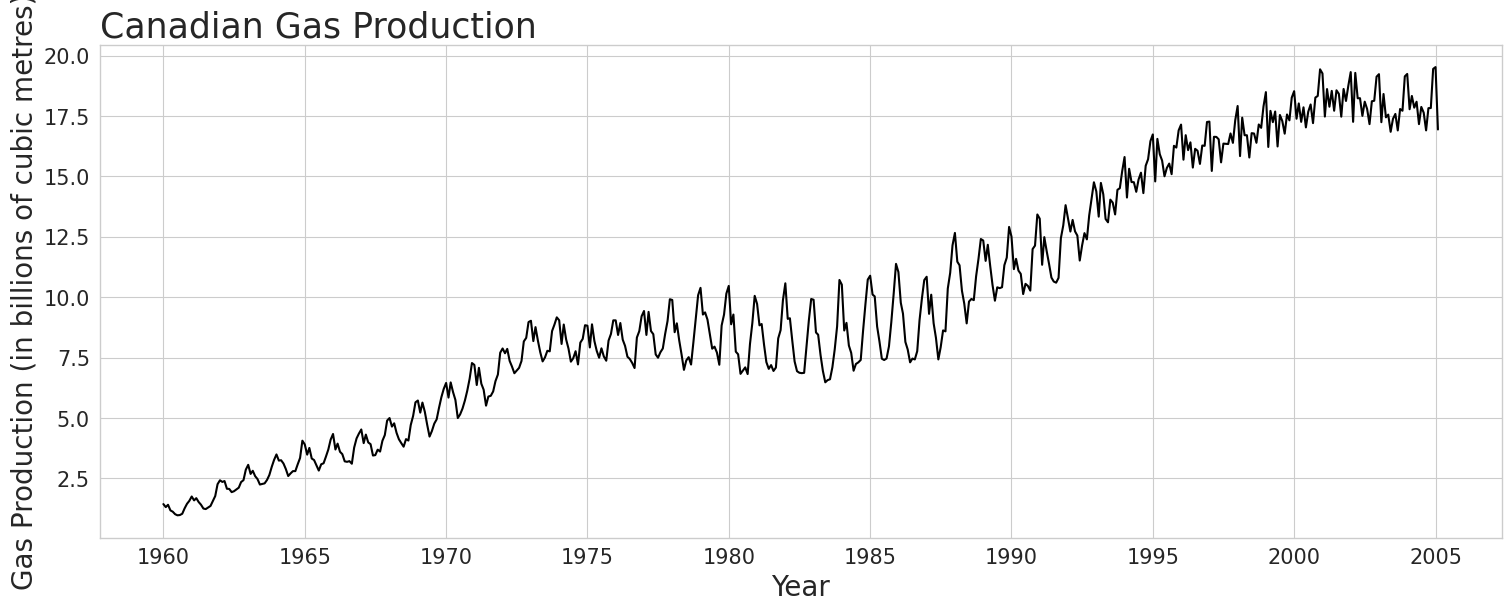

In [242]:
plot_series_fpp(cgas_nx, title="Canadian Gas Production", xlabel="Year", ylabel="Gas Production (in billions of cubic metres)")

We can create a manual train/test split with the usual 80/20 proportions by first defining the temporal index where the split occurs:

In [243]:
train_end = int(np.floor(len(cgas_nx) * 0.8))
train_end

433

And now the manual split is simply done by slicing the data as follows:

In [244]:
cgas_train = cgas_nx.iloc[:train_end]
cgas_test = cgas_nx.iloc[train_end:]


It is always a good idea to check the result:

In [245]:
cgas_train.tail(1)


,unique_id,ds,y
432,Canadian gas production,1996-01-01,17.147


In [246]:
cgas_test.head(1)

,unique_id,ds,y
433,Canadian gas production,1996-02-01,15.693


We can extract the last position/date of the training set and the first position/date of the testing set as follows:

In [247]:
cgas_train.index[-1], cgas_train.ds.values[-1] 

(432, np.datetime64('1996-01-01T00:00:00.000000000'))

In [248]:
cgas_test.index[0], cgas_test.ds.values[0]

(433, np.datetime64('1996-02-01T00:00:00.000000000'))

And the shapes of the training and testing sets as follows:

In [249]:
cgas_train.shape, cgas_test.shape

((433, 3), (109, 3))

We can also extract the date of the split:

In [250]:
train_end_date = cgas_train['ds'].values[-1]
train_end_date.astype('datetime64[D]')

np.datetime64('1996-01-01')

So the split could also be done taking a date such as that one as a reference:

In [251]:
cgas_train = cgas_nx.query("ds <= @train_end_date")
cgas_test = cgas_nx.query("ds > @train_end_date")

Or equivalently:

In [252]:
train_end_date_str = "1996-01-01"
cgas_train = cgas_nx.query("ds <= @train_end_date_str")
cgas_test = cgas_nx.query("ds > @train_end_date")

Which results in the same train/test split:

In [253]:
cgas_train.tail(1)

,unique_id,ds,y
432,Canadian gas production,1996-01-01,17.147


It is also useful to visualize the split in a time plot:

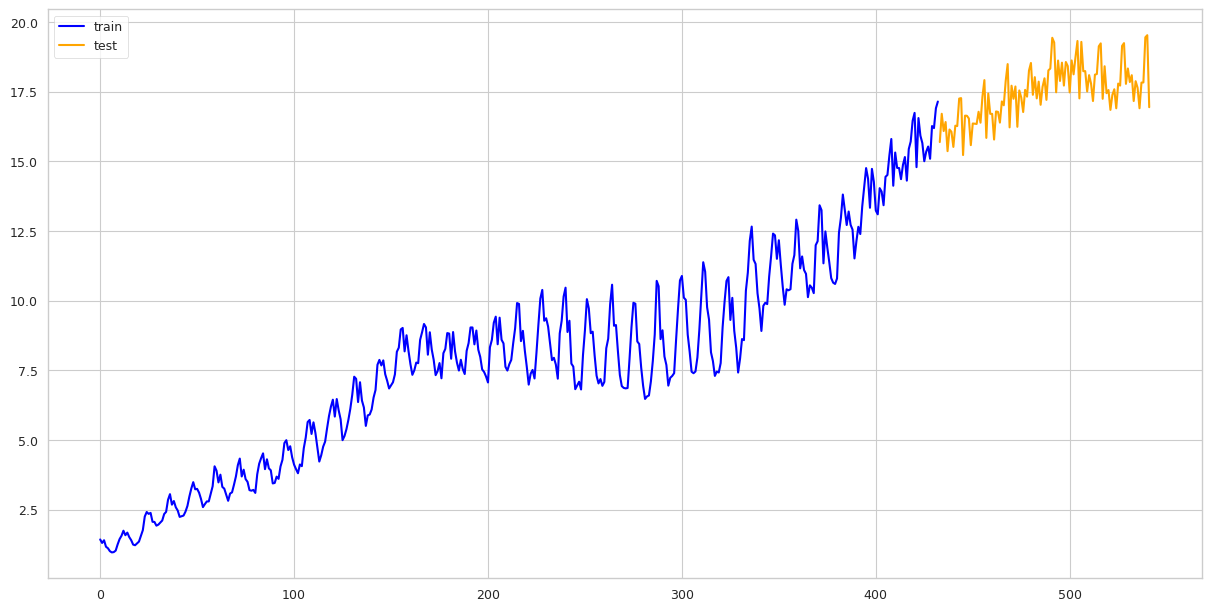

In [254]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(cgas_train['y'], label='train', color='blue')
ax.plot(cgas_test['y'], label='test', color='orange')
ax.legend(["train", "test"])
plt.show();plt.close()


::: {.callout-note icon=false}

#### Train/test split and forecasting horizon

We got used to the 80/20 proportion for the splits in the context of the basic regression problem of Machine Learning. But in forecasting things are different. For example, with a monthly time series, we are often interested in making predictions for a given **forecasting horizon**, usually denoted h. If we need the prediction for next moth, h = 1, for the next three months (a quarter), then h = 3, and if we want a whole year then h = 12. These are all typical scenarios, and if we want to evaluate the performance of a model, this has clear consequences on the way we evaluate our models. The evaluation should reflect the way that our forecasting model is going to be used in practice, and what you *model update* policy is going to be. 

That is, imagine it is December, and your model is tasked with predicting the next twelve months. You make your forecast with h = 12, and then the new January data comes in. In many cases, you will want to *retrain* your model using that new data, to keep it as updated as possible. If that is the case, then your model performance valuation should reflect that, But using a single test set with length equal to the forecasting horizon is not going to be enough in most cases, and it will not give you any idea about the variance in your model prediction accuracy. In such cases, we need to consider cross validation strategies such as those described below. 

In other cases, for example for short term prediction (we need a forecast for tomorrow or for the next hour), retraining the model is not possible or becomes too costly. In any case, you model evaluation should always reflect how the model is going to be used and how often it will be updated. 

:::


::: {.callout-note icon=false}

#### Cross validation in forecasting

**Highly recommended reading and video watching:** [@hyndman2021fpp3, Section 5.10](https://otexts.com/fpp3/skl_cv.html#skl_cv). We will use some figures from that section below.

We know by now that we should use a validation set to assess the performance of our models and to fine-tune the hyperparameters of our models. In time series forecasting, we should use a validation set that is also time-aware. That is, any validation data should be in the future of the training data. And if we plan to use cross-validation, the same time-awareness extends to the folds of the cross-validation. 

There are several different approaches to cross validation in time series forecasting. The **expanding window** approach is the most common one. In this approach, the training set starts with an initial window and grows with each fold by adding some points at the end of the training set. The number of points added is called the **step**. The test set is always comprised by a fixed number of points following the training set. That fixed number of points in the test set is equal to our **forecasting horizon** (usually represented as `fh` in many forecasting libraries), so that the validation reflects the way the model will be used. Expanding windows with fh=1 are illustrated in the figure below, from [@hyndman2025fpppy], Section 5.10. The blue dots represent the training set, the orange dot represents the test set.

![](https://otexts.com/fpp3/fpp_files/figure-html/cv1-1.png){width=80% fig-align="center"}

A case when fh=4 is illustrated in the figure below, also from [@hyndman2025fpppy, Section 5.10].

![](https://otexts.com/fpp3/fpp_files/figure-html/cv4-1.png){width=80% fig-align="center"}

The expanding window is also often called **rolling forecasting origin**.

:::




In the Nixtlaverse StatsForecast library we need to specify a model before we can create a cross validation strategy. So let us introduce some very simple forecasting models and then we will resume this discussion.

# Baseline Models

::: {.callout-note icon=false}

#### What is a baseline model?

In the following sessions we are going to introduce some fairly sophisticated forecasting methods. Classical statistical models in the Arima and Exponential Smoothing families,  Machine Learning and Deep Learning Models, etc.  But these models come at a computational and conceptual cost, and their interpretation is often not immediate or even possible On the other hand, we can consider some very simple models based on the characteristics of the time series. We will then use these models as a baseline against which we compare the fancier models. If they are not substantially better than the very basic baselines, then they are probably not worth the cost.

**Note:** we don't have time to cover one of the classical families of models, the Exponential Smoothing models. We refer you to [@hyndman2025fpppy Chapter 8 for that],


## The naive model

Arguably the simplest forecasting strategy we can think of. When we need to forecast a future value we simply *repeat the last observed value*, as many times as the forecasting horizon requires. In particular this means that the time plot of the forecast is a flat, horizontal line.

In StatsForecast we define one such model as follows (here 'MS' indicates month start):

In [255]:
naive_method = Naive()
cgas_naive = StatsForecast(models=[naive_method], freq="MS")

Recall that the last row of our training set is:

In [256]:
cgas_train.tail(1)

,unique_id,ds,y
432,Canadian gas production,1996-01-01,17.147


So if we fit the naive model and make a forecast with horizon h = 3 we get:

In [257]:
cgas_naive.fit(cgas_train)
cgas_naive.predict(h=3)

,unique_id,ds,Naive
0,Canadian gas production,1996-02-01,17.147
1,Canadian gas production,1996-03-01,17.147
2,Canadian gas production,1996-04-01,17.147


As we can see, the prediction is flat and equals the last value in the training dataset.

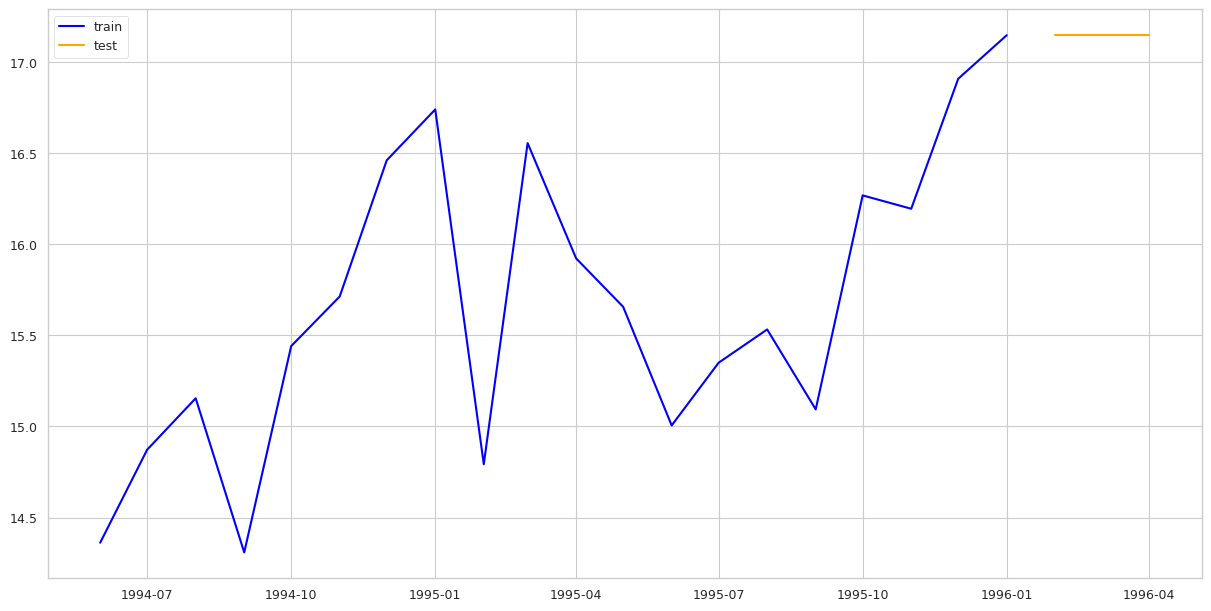

In [258]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(cgas_train.set_index('ds')['y'].tail(20), label='train', color='blue')
ax.plot(cgas_naive.predict(h=3).set_index('ds')[['Naive']], label='test', color='orange')
ax.legend(["train", "test"])
plt.show();plt.close()

## Cross validation for naive forecasting

Now that we have specified a model, we can select a forecasting horizon, In this example, let us assume that we want to forecast the next quarter (three months) of gas production, so we take:

In [259]:
fh = 3

Now we can use the `cross_validation` function to apply the rolling window validation method. 

In [260]:
cgas_cv_df = cgas_naive.cross_validation(
    df = cgas_nx,
    h = fh,
    step_size = 1,
    n_windows = 4)

The code above uses `n_windows = 4`. This is equal to the number of performance measures that we will obtain, and here we are setting a particularly low value for teaching purposes. If you refer to the pictures above it is as we are only considering the bottom four rows of the picture. The object returned by `cross_validation` is this data frame:


In [261]:
cgas_cv_df

,unique_id,ds,cutoff,y,Naive
0,Canadian gas production,2004-09-01,2004-08-01,16.907,17.641
1,Canadian gas production,2004-10-01,2004-08-01,17.827,17.641
2,Canadian gas production,2004-11-01,2004-08-01,17.832,17.641
3,Canadian gas production,2004-10-01,2004-09-01,17.827,16.907
4,Canadian gas production,2004-11-01,2004-09-01,17.832,16.907
5,Canadian gas production,2004-12-01,2004-09-01,19.453,16.907
6,Canadian gas production,2004-11-01,2004-10-01,17.832,17.827
7,Canadian gas production,2004-12-01,2004-10-01,19.453,17.827
8,Canadian gas production,2005-01-01,2004-10-01,19.528,17.827
9,Canadian gas production,2004-12-01,2004-11-01,19.453,17.832


How does this work? Note that the `cutoff` column takes four different values, corresponding to our choice of `n_windows = 4`

In [262]:
cgas_cv_df['cutoff'].value_counts()

cutoff
2004-08-01    3
2004-09-01    3
2004-10-01    3
2004-11-01    3
Name: count, dtype: int64

+ Besides, each cutoff value shows the temporal index of the **last element of the training data used for that fold**. And since the forecasting horizon equals 3, there are three rows associated with that cutoff. 
+ The ds values for those three rows are the **data points used as validation in that fold**. 

We can make that explicit by adding a column that indicates the fold/sliding window:

In [263]:
cutoff_order = cgas_cv_df["cutoff"].drop_duplicates().sort_values()
cutoff_to_fold = {cutoff: f"fold_{i+1}" for i, cutoff in enumerate(cutoff_order)}

cgas_cv_df["fold"] = cgas_cv_df["cutoff"].map(cutoff_to_fold)

cgas_cv_df

,unique_id,ds,cutoff,y,Naive,fold
0,Canadian gas production,2004-09-01,2004-08-01,16.907,17.641,fold_1
1,Canadian gas production,2004-10-01,2004-08-01,17.827,17.641,fold_1
2,Canadian gas production,2004-11-01,2004-08-01,17.832,17.641,fold_1
3,Canadian gas production,2004-10-01,2004-09-01,17.827,16.907,fold_2
4,Canadian gas production,2004-11-01,2004-09-01,17.832,16.907,fold_2
5,Canadian gas production,2004-12-01,2004-09-01,19.453,16.907,fold_2
6,Canadian gas production,2004-11-01,2004-10-01,17.832,17.827,fold_3
7,Canadian gas production,2004-12-01,2004-10-01,19.453,17.827,fold_3
8,Canadian gas production,2005-01-01,2004-10-01,19.528,17.827,fold_3
9,Canadian gas production,2004-12-01,2004-11-01,19.453,17.832,fold_4


The last remaining piece to understand is the `Naive` column, that contains the predictions (forecasts) of the model for the points in that fold. In this example, using the Naive model, you can see that the forecast is constant (flat) for each fold and its value equals the value of the time series at the last point of the training segment of that fold (the cutoff for that fold).

::: {.callout-tip  icon=false}

### Exercise 001

+ Change the forecasting horizon parameter to `fh = 12` and run the cv code again. What happens?
+ Also play with different values of the step parameter to see what happens.

:::

# Performance evaluation in forecasting

In order to do that, we need to calculate some error metrics. We recommend reading [Section 5.8 of @hyndman2025fpppy](https://otexts.com/fpppy/nbs/05-toolbox.html#sec-accuracy) for a detailed explanation of these metrics.

::: {.callout-note icon=false}

### Metrics for time series forecasting. Validation and test metrics.

Since forecasting time series is essentially a regression problem, we can use the same metrics we used for regression problems. The most common metrics are:
+ Mean Absolute Error (MAE). Minimizing this means we will predict the median of the time series. 
+ Root Mean Squared Error (RMSE). Minimizing this means we will predict the mean of the time series.  
+ Mean Absolute Percentage Error (MAPE).
+ Symmetric Mean Absolute Percentage Error (sMAPE). Hyndman recommends not using it, because it can be numerically unstable. 
+ Mean absolute scaled error (MASE).

 The first two measures MAE and RMSE are, as we know, *scale dependent*. But when we use them to compare different models for the same time series, the scale dependency is not a problem. 

To compute the validation metrics, we need to calculate the error metrics for each fold of the cross-validation. We can then average the error metrics to get a single value for each metric. 

:::

Statsforecast provides an `evaluate` function that we can use as follows:

In [264]:
cgas_naive_eval = evaluate(cgas_cv_df, metrics=[rmse, mape], models=["Naive"])
cgas_naive_eval

,unique_id,cutoff,metric,Naive
0,Canadian gas production,2004-08-01,rmse,0.451
1,Canadian gas production,2004-09-01,rmse,1.652
2,Canadian gas production,2004-10-01,rmse,1.359
3,Canadian gas production,2004-11-01,rmse,1.448
4,Canadian gas production,2004-08-01,mape,0.022
5,Canadian gas production,2004-09-01,mape,0.078
6,Canadian gas production,2004-10-01,mape,0.057
7,Canadian gas production,2004-11-01,mape,0.074


As you see we get an evaluation value for each metric and fold combination. We can summarize the performance by computing metric averages over all the folds:

In [265]:
cgas_naive_eval.groupby("metric")['Naive'].mean()

metric
mape    0.058
rmse    1.227
Name: Naive, dtype: float64

# Other baseline models. Model comparison.

::: {.callout-note icon=false}

### Baseline models assumptions

See [@hyndman2025fpppy, Section 5.2](https://otexts.com/fpppy/nbs/05-toolbox.html#sec-simple-methods)

The so called **baseline or benchmark models** are all based on the idea that the future behavior is likely to be similar to the *basic patterns* observed in the past. The difference between these models is how they define the *past* and how that past information is used to make predictions.

+ For example, we can simply decide to use the last observed value as the prediction for the future. This is what we did in tne `Naive` model (also called *last observed* model). 
+ We could instead use the mean of the (past values of the) time series as prediction. This is the *mean method*, implemented in the Nixtlaverse as `HistoricAverage`. Note that this also returns a *flat* prediction, as in the naive method. 
+ Or, for seasonal time series, we could use the last observed value from the same season of the preceding seasonal period as the prediction for the future. This is the *seasonal naïve method*, provided as `SeasonalNaive` in Nixtla. 
+ The `drift` model makes the simplest possible estimation of trend, in that it connects the first and last points in the past data with a line, and extends that line into the future to make predictions. Nixtla implements this as `RandomWalkWithDrift`.

:::

Check the [Nixtla documentation](https://nixtlaverse.nixtla.io/statsforecast/src/core/models.html#baseline-models) for more details and other options. Also take the opportunity to browse the model collection offered  by Statsforecast (and that's only one part of the Nixtlaverse).




::: {.callout-warning icon=false}

### Seasonal models

Keep in mind that when using seasonal naive models, you need to specify the seasonal period of the time series. **Be careful: choosing the wrong seasonal period can lead to very poor predictions!** Always think about the sampling frequency of the data and the compatible seasonal periods.

This is the first time we warn you, but it will not be the last!

:::

Let us apply these baseline models to the Canadian gas production dataset. We will repeat the Naive model in the list for ease of model comparison below. 

We begin by creating instances of the model classes and putting them in a model list: 

In [266]:
freq = 12
cgas_mean = HistoricAverage()
cgas_naive = Naive()
cgas_seasonal = SeasonalNaive(freq)
cgas_drift = RandomWalkWithDrift()

cgas_models = [cgas_mean, cgas_naive, cgas_seasonal, cgas_drift]

Now we can pass that list to Statsforecast:

In [267]:
cgas_baselines = StatsForecast(models=cgas_models, freq="MS")

Before moving on, we need to select a forecasting horizon, Again, we assume that we want to forecast the next quarter (three months) of gas production:

In [268]:
fh = 3

Now we can use the same `cross_validation` function with this `cgas_baselines` object. But this time, in line with the idea of 10 fold cross validation, we use ten windows: 

In [269]:
cgas_cv_df = cgas_baselines.cross_validation(
    df = cgas_nx,
    h = fh,
    step_size = 1,
    n_windows = 10)

cgas_cv_df.shape

(30, 8)

In [270]:
cgas_cv_df.head()

,unique_id,ds,cutoff,y,HistoricAverage,Naive,SeasonalNaive,RWD
0,Canadian gas production,2004-03-01,2004-02-01,18.333,9.591,17.782,18.413,17.813
1,Canadian gas production,2004-04-01,2004-02-01,17.848,9.591,17.782,17.447,17.844
2,Canadian gas production,2004-05-01,2004-02-01,18.093,9.591,17.782,17.560,17.875
3,Canadian gas production,2004-04-01,2004-03-01,17.848,9.608,18.333,17.447,18.365
4,Canadian gas production,2004-05-01,2004-03-01,18.093,9.608,18.333,17.560,18.397


**Be careful here!** Even though we passed our list of model names (such as `cgas_seasonal`), the `cross_validation` function returns column names based on the model classes. That is why we are going to extract those column names to pass them to the evaluation function.

In [271]:
model_columns = cgas_cv_df.columns[-len(cgas_models):].tolist()
model_columns

['HistoricAverage', 'Naive', 'SeasonalNaive', 'RWD']

And we evaluate the performance of each model as before:

In [272]:
cgas_baselines_eval = evaluate(cgas_cv_df, metrics=[rmse, mape], models=model_columns)
cgas_baselines_eval


,unique_id,cutoff,metric,HistoricAverage,Naive,SeasonalNaive,RWD
0,Canadian gas production,2004-02-01,rmse,8.502,0.367,0.388,0.326
1,Canadian gas production,2004-03-01,rmse,8.104,0.743,0.427,0.807
2,Canadian gas production,2004-04-01,rmse,8.099,0.419,0.458,0.448
3,Canadian gas production,2004-05-01,rmse,7.928,0.609,0.340,0.657
4,Canadian gas production,2004-06-01,rmse,7.833,0.517,0.287,0.504
5,Canadian gas production,2004-07-01,rmse,7.800,0.578,0.037,0.622
6,Canadian gas production,2004-08-01,rmse,7.850,0.451,0.068,0.451
7,Canadian gas production,2004-09-01,rmse,8.707,1.652,0.191,1.591
8,Canadian gas production,2004-10-01,rmse,9.259,1.359,0.251,1.296
9,Canadian gas production,2004-11-01,rmse,8.995,1.448,0.541,1.433


Looks good. We used 10 folds for two metrics, so we get 20 rows. Now we can et average performance measures over the folds:

In [273]:
cgas_baselines_eval.groupby("metric")[model_columns].mean()

,HistoricAverage,Naive,SeasonalNaive,RWD
metric,,,,
mape,0.461,0.038,0.015,0.039
rmse,8.308,0.814,0.299,0.814


As could be expected, since the Canadian gas time series is strongly seasonal, we get the best results using the only baseline method that exploits that seasonality.

::: {.callout-note icon=false}

### Predictions and visualization

We can also obtain and visualize the model future forecasts (predictions), based on the forecasting horizon we are using.

:::

In [274]:
cgas_baselines_preds = cgas_baselines.forecast(df = cgas_nx, h=fh)
cgas_baselines_preds

,unique_id,ds,HistoricAverage,Naive,SeasonalNaive,RWD
0,Canadian gas production,2005-03-01,9.777,16.944,18.333,16.973
1,Canadian gas production,2005-04-01,9.777,16.944,17.848,17.001
2,Canadian gas production,2005-05-01,9.777,16.944,18.093,17.030


Note that these forecasts extend into the future for which we have no observed data available for comparison (the last observed date in the time series is 2005-02-01). 

We can also use `predict`, but this requires calling `fit` first. The result is exactly the same in this case. 

In [275]:
cgas_baselines.fit(cgas_nx)
cgas_baselines.predict(h=fh)

,unique_id,ds,HistoricAverage,Naive,SeasonalNaive,RWD
0,Canadian gas production,2005-03-01,9.777,16.944,18.333,16.973
1,Canadian gas production,2005-04-01,9.777,16.944,17.848,17.001
2,Canadian gas production,2005-05-01,9.777,16.944,18.093,17.030


In [276]:
plot_df = cgas_baselines_preds.copy()
plot_df['ds'] = pd.to_datetime(plot_df['ds'])
plot_df.set_index('ds', inplace=True)
plot_df.head()


,unique_id,HistoricAverage,Naive,SeasonalNaive,RWD
ds,,,,,
2005-03-01,Canadian gas production,9.777,16.944,18.333,16.973
2005-04-01,Canadian gas production,9.777,16.944,17.848,17.001
2005-05-01,Canadian gas production,9.777,16.944,18.093,17.030


In [277]:
plot_df['HistoricAverage']

ds
2005-03-01    9.777
2005-04-01    9.777
2005-05-01    9.777
Name: HistoricAverage, dtype: float64

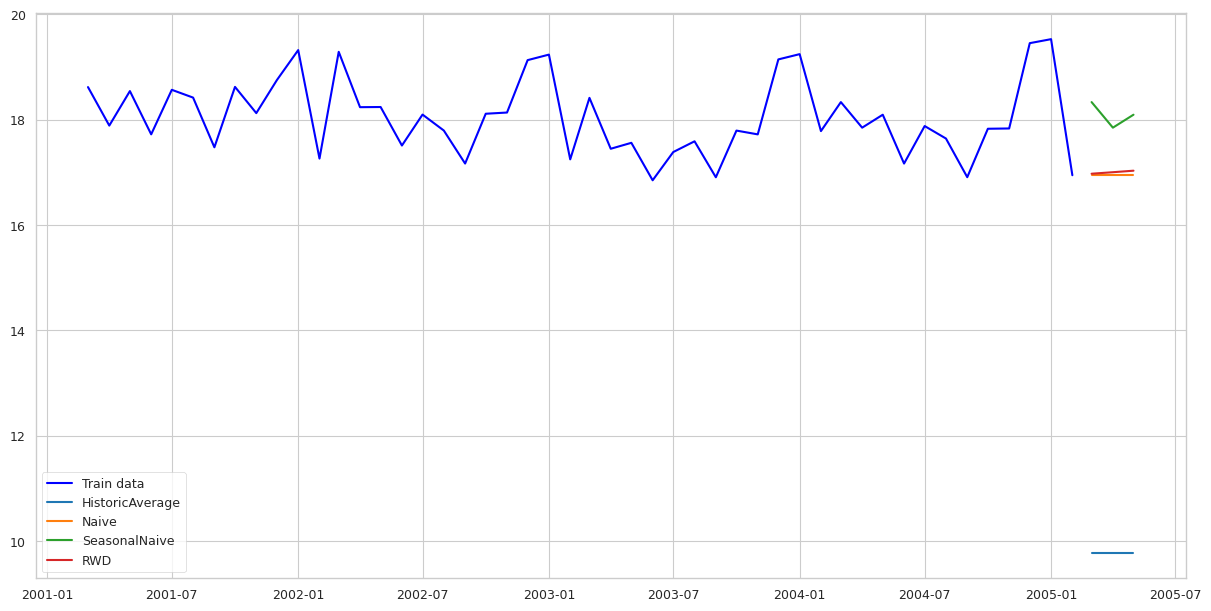

In [278]:

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(cgas_nx.set_index('ds', inplace=False)['y'][-48:], label='train', color='blue')
for model in model_columns:
    ax.plot(plot_df[model], label=model, color=plt.cm.tab10(model_columns.index(model))) 
ax.legend(["Train data"] + model_columns)
plt.show();plt.close()

::: {.callout-tip  icon=false}

### Exercise 003

+ Again, change the forecasting horizon parameter to `fh = 12` and run the last sections of code (including all the baseline models). How do they compare in this case?
+ How many windows/folds of cross validation can you use?

:::

# Decomposition based modeling

::: {.callout-note icon=false}

#### Time series dynamics and decomposition

In many cases when the dynamic of a time series is dominated by a strong component, either trend or seasonality, the naive models that pay attention to that component are the best ones. But when both components are important, naive models struggle to capture the complexity of the time series, as we have seen in the Canadian Gas example. 

In a preceding session we introduced the MSTL method, and we are going to use it here as an easily accessible and interpretable method to showcase the typical situation in which we will apply a more advanced method and compare it with the baselines. 


:::



We have already seen how to implement this model in a previous session, so we repeat the code:

In [279]:
model_mstl = [MSTL(season_length=[12])]
cgas_mstl = StatsForecast(models=model_mstl, freq='MS')

We are going to use the same folds as we used for the baseline models. 

In [280]:
cgas_cv_df_mstl = cgas_mstl.cross_validation(
    df = cgas_nx,
    h = fh,
    step_size = 1,
    n_windows = 10)

cgas_cv_df_mstl.shape

(30, 5)

And this is how the output looks:

In [281]:
cgas_cv_df_mstl.head()

,unique_id,ds,cutoff,y,MSTL
0,Canadian gas production,2004-03-01,2004-02-01,18.333,18.885
1,Canadian gas production,2004-04-01,2004-02-01,17.848,18.167
2,Canadian gas production,2004-05-01,2004-02-01,18.093,18.439
3,Canadian gas production,2004-04-01,2004-03-01,17.848,17.857
4,Canadian gas production,2004-05-01,2004-03-01,18.093,18.123


Recall that we had this for the baseline models:

In [290]:
cgas_cv_df.head()

,unique_id,ds,cutoff,y,HistoricAverage,Naive,SeasonalNaive,RWD,MSTL
0,Canadian gas production,2004-03-01,2004-02-01,18.333,9.591,17.782,18.413,17.813,18.885
1,Canadian gas production,2004-04-01,2004-02-01,17.848,9.591,17.782,17.447,17.844,18.167
2,Canadian gas production,2004-05-01,2004-02-01,18.093,9.591,17.782,17.560,17.875,18.439
3,Canadian gas production,2004-04-01,2004-03-01,17.848,9.608,18.333,17.447,18.365,17.857
4,Canadian gas production,2004-05-01,2004-03-01,18.093,9.608,18.333,17.560,18.397,18.123


But since the folds are the same we can easily incorporate the information for MSTL as an extra column:

In [283]:
cgas_cv_df['MSTL'] = cgas_cv_df_mstl['MSTL']

And also update the models columns list:

In [284]:
model_columns.append('MSTL')
model_columns

['HistoricAverage', 'Naive', 'SeasonalNaive', 'RWD', 'MSTL']

Now we simply can call evaluate to get an updated table including MSTL:

In [285]:
cgas_models_eval = evaluate(cgas_cv_df, metrics=[rmse, mape], models=model_columns)
cgas_models_eval

,unique_id,cutoff,metric,HistoricAverage,Naive,SeasonalNaive,RWD,MSTL
0,Canadian gas production,2004-02-01,rmse,8.502,0.367,0.388,0.326,0.418
1,Canadian gas production,2004-03-01,rmse,8.104,0.743,0.427,0.807,0.034
2,Canadian gas production,2004-04-01,rmse,8.099,0.419,0.458,0.448,0.090
3,Canadian gas production,2004-05-01,rmse,7.928,0.609,0.340,0.657,0.203
4,Canadian gas production,2004-06-01,rmse,7.833,0.517,0.287,0.504,0.301
5,Canadian gas production,2004-07-01,rmse,7.800,0.578,0.037,0.622,0.330
6,Canadian gas production,2004-08-01,rmse,7.850,0.451,0.068,0.451,0.191
7,Canadian gas production,2004-09-01,rmse,8.707,1.652,0.191,1.591,0.406
8,Canadian gas production,2004-10-01,rmse,9.259,1.359,0.251,1.296,0.549
9,Canadian gas production,2004-11-01,rmse,8.995,1.448,0.541,1.433,0.519


And finally extract the average performance metrics for all models across the folds:

In [291]:
cgas_models_eval.groupby("metric")[model_columns].mean()

,HistoricAverage,Naive,SeasonalNaive,RWD,MSTL
metric,,,,,
mape,0.461,0.038,0.015,0.039,0.015
rmse,8.308,0.814,0.299,0.814,0.304


### Visualization

To add the MSTL predictions to the visualization we need to call `forecast` like this: 

In [287]:
cgas_mstl_preds = cgas_mstl.forecast(df = cgas_nx, h=fh)
cgas_mstl_preds

,unique_id,ds,MSTL
0,Canadian gas production,2005-03-01,18.462
1,Canadian gas production,2005-04-01,17.739
2,Canadian gas production,2005-05-01,18.014


Now we add them to the predictions data frame:

In [288]:
cgas_models_preds = cgas_baselines_preds.copy()
cgas_models_preds['MSTL'] = cgas_mstl_preds['MSTL']
cgas_models_preds

,unique_id,ds,HistoricAverage,Naive,SeasonalNaive,RWD,MSTL
0,Canadian gas production,2005-03-01,9.777,16.944,18.333,16.973,18.462
1,Canadian gas production,2005-04-01,9.777,16.944,17.848,17.001,17.739
2,Canadian gas production,2005-05-01,9.777,16.944,18.093,17.030,18.014


And we only need updating the `plot_df` data frame to get the desired graphic, combining MSTL and the baselines.

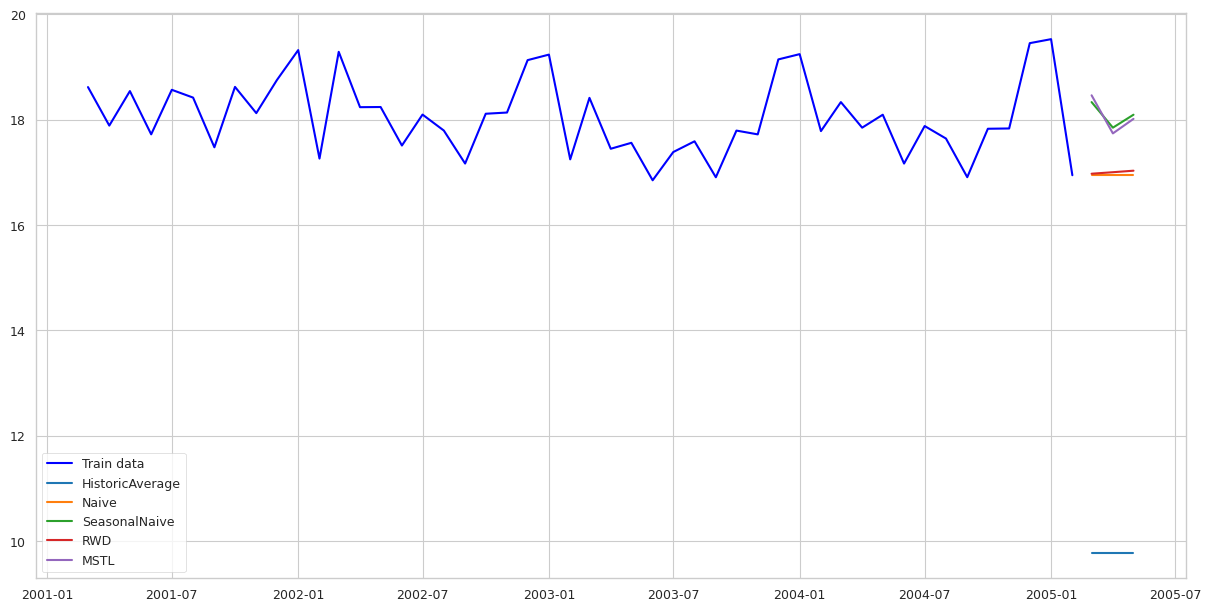

In [292]:
plot_df = cgas_models_preds.copy()
plot_df['ds'] = pd.to_datetime(plot_df['ds'])
plot_df.set_index('ds', inplace=True)
plot_df.head()



fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(cgas_nx.set_index('ds', inplace=False)['y'][-48:], label='train', color='blue')
for model in model_columns:
    ax.plot(plot_df[model], label=model, color=plt.cm.tab10(model_columns.index(model))) 
ax.legend(["Train data"] + model_columns)
plt.show();plt.close()

::: {.callout-tip  icon=false}

### Exercise 004

Repeat the `fh = 12` once more, now including the MSTL. What do you think? Now *zoom out* in the previous plot (you only need to change a number) and think again. 


:::

______


::: {.callout-note  icon=false}

## In the Next Sessions

We will meet the most important family of classical models, the SARIMA models. Then we will add additional time series as exogenous predictors (SARIMAX models). We will also discuss *autoarima* strategies. 

:::

# References